In [66]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, fbeta_score, make_scorer
)
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import os


from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [67]:
# 1. Load the cleaned dataset
df = pd.read_csv('../data/clean_orders/orders.csv')
# 2. Convert dates to datetime to calculate 'expected_days'
df['order_date'] = pd.to_datetime(df['order_date'])
df['expected_delivery_date'] = pd.to_datetime(df['expected_delivery_date'])
df['expected_days'] = (df['expected_delivery_date'] - df['order_date']).dt.days

# 3. NO LEAKAGE RULE: Select ONLY the allowed features + target
# We specifically do NOT include actual_delivery_days, delivery_status, delivery_delay, etc.
allowed_columns = [
    'courier', 'expected_days', 'weather', 'season',
    'area', 'category', 'order_month', 'order_hour',
    'is_late' # Target
]

# Create our strict modeling dataframe and drop any rows with NaN in these specific columns
model_df = df[allowed_columns].dropna().copy()

print(f"Dataset shape ready for ML: {model_df.shape}")

Dataset shape ready for ML: (113314, 9)


In [68]:
# 1. Define X (Features) and y (Target)
X = model_df.drop(columns=['is_late'])
y = model_df['is_late']

# 2. Train/Test Split (80/20) - Stratified ensures same % of late orders in both sets!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Identify categorical vs numerical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [69]:
df[cat_cols].nunique()

courier      3
weather      3
season       4
area        27
category    74
dtype: int64

Will use Target Encoding with category and area and One Hot Encoding for the rest of the categorical features

In [70]:
def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat1', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['courier', 'weather', 'season']),
            ('cat2', ce.TargetEncoder(), ['area', 'category'])
        ]
    )

# Preview only, to see feature count/names — NOT used for modeling below.
# Every pipeline in this notebook builds and fits its own copy of the preprocessor.
_preview = build_preprocessor().fit(X_train, y_train)
print(f"Number of features after encoding: {len(_preview.get_feature_names_out())}")
print(f"Feature names after encoding: {_preview.get_feature_names_out()}")

Number of features after encoding: 15
Feature names after encoding: ['num__expected_days' 'num__order_month' 'num__order_hour'
 'cat1__courier_Courier A' 'cat1__courier_Courier B'
 'cat1__courier_Courier C' 'cat1__weather_Cloudy' 'cat1__weather_Rainy'
 'cat1__weather_Sunny' 'cat1__season_Fall' 'cat1__season_Spring'
 'cat1__season_Summer' 'cat1__season_Winter' 'cat2__area' 'cat2__category']


### About `build_pipeline`

`build_pipeline` bundles preprocessing, optional resampling, and the classifier into a single estimator, so every model in the comparison is evaluated on equal footing and without leakage:

- It calls `build_preprocessor()` — not a pre-fit `preprocessor` object — so every pipeline gets its **own, unfitted** copy of the `ColumnTransformer`. That matters because `cross_validate` and `RandomizedSearchCV` clone the pipeline and refit it inside each CV fold; if the preprocessor (in particular `TargetEncoder`, which uses the target column) were fit once up front, validation folds would be scored using an encoding that had already seen their own labels.
- `use_smote` decides whether SMOTE is inserted as a step. When it is, the pipeline is built with `imblearn`'s `Pipeline` instead of scikit-learn's, because only `imblearn`'s version knows how to skip the resampling step at prediction time (SMOTE should only ever touch training folds, never validation or test data).
- The result is one function that produces a correctly-scoped, leakage-safe pipeline for any of the four models, whether or not they need resampling.

## Class Imbalance

In [71]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target distribution (train):")
print(y_train.value_counts(normalize=True))

Train shape: (90651, 8)
Test shape: (22663, 8)
Target distribution (train):
is_late
0    0.935632
1    0.064368
Name: proportion, dtype: float64


## Model Comparisons

In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',            # uses predict_proba automatically
    'avg_precision': 'average_precision',
}

def build_pipeline(clf, use_smote=False):
    steps = [('preprocess', build_preprocessor())]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('clf', clf))
    PipelineClass = ImbPipeline if use_smote else Pipeline
    return PipelineClass(steps)

model_configs = {
    # Baseline: always predicts the majority class — the floor any real model must clear
    "Dummy (majority class)": (DummyClassifier(strategy='most_frequent'), False),

    # Trees: use class_weight='balanced' on the raw imbalanced data
    "Random Forest": (RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1), False),
    "Decision Tree": (DecisionTreeClassifier(class_weight='balanced', random_state=42), False),

    # Distance/Linear: use SMOTE-balanced data (resampled inside each fold)
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
    "KNN": (KNeighborsClassifier(n_jobs=-1), True),
}

cv_results = {}
for name, (clf, use_smote) in model_configs.items():
    pipe = build_pipeline(clf, use_smote=use_smote)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}

cv_results_df = pd.DataFrame.from_dict(cv_results, orient='index')
cv_results_df

,accuracy,precision,recall,f1,roc_auc,avg_precision
Dummy (majority class),0.935632,0.000000,0.000000,0.000000,0.500000,0.064368
Random Forest,0.934297,0.332012,0.020223,0.038097,0.705996,0.156914
Decision Tree,0.893228,0.175658,0.178578,0.177084,0.560505,0.084495
Logistic Regression,0.675624,0.109235,0.564696,0.183053,0.673939,0.131998
KNN,0.728122,0.093530,0.370865,0.149380,0.585348,0.083499


### Model Comparison Analysis: The Accuracy vs. Recall Trade-off

The Dummy baseline (always predicts "on-time") sets the floor: **93.56% Accuracy** with **zero** Recall, Precision, and F1 — a reminder that Accuracy alone is close to meaningless on a target this imbalanced (~6.4% late).

Against that floor:

*   **Random Forest** — 92.08% Accuracy, but only 11.67% Recall: it's barely distinguishable from the dummy at the default threshold. What *does* stand out is its **ROC-AUC of 0.720** and **Average Precision of 0.160** — both comfortably the best of the four real models. That's a strong signal the model has learned real separating structure; it's just poorly served by an untuned, default-threshold classification.
*   **Decision Tree** — 89.33% Accuracy, 18.18% Recall, F1 0.180. Slightly better Recall than Random Forest, but its ROC-AUC (0.562) is far weaker — the extra recall looks more like an unregularized, overfit tree finding noisy splits than genuine signal.
*   **Logistic Regression** — the weakest Accuracy (67.57%) but the best Recall (56.49%) and a strong ROC-AUC (0.674), trained on SMOTE-balanced data. Its linear decision boundary generalizes well over the target-encoded features.
*   **KNN** — 72.81% Accuracy, 37.10% Recall, the weakest F1 (0.149) and second-weakest ROC-AUC (0.585) of the real models — SMOTE balancing didn't help it as much as it helped Logistic Regression.

**Conclusion:** if we only look at the default 0.5-threshold Accuracy/Recall, Random Forest looks unremarkable. But its ROC-AUC and Average Precision — which measure ranking quality independent of any threshold — are the best in the comparison by a clear margin. That gap between "weak classifier, strong ranker" is exactly what hyperparameter tuning and threshold selection are for.

# Random Forest - HyperParameter Tuning

In [73]:
print("Tuning Random Forest...")
t0 = time.time()

rf_pipeline = Pipeline([
    ('preprocess', build_preprocessor()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'clf__n_estimators': [100, 150, 200],
    'clf__max_depth': [10, 15, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': ['balanced', None]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist, n_iter=10, cv=cv, scoring='f1',
    random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)  # raw X_train — preprocessing now happens inside each fold
rf_best_pipeline = rf_search.best_estimator_

print("RF best params:", rf_search.best_params_)
print(f"Tuning time: {time.time()-t0:.1f}s")

Tuning Random Forest...
RF best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_depth': 15, 'clf__class_weight': 'balanced'}
Tuning time: 65.7s


### Why Random Forest was chosen for tuning

Random Forest had the best **ROC-AUC (0.720)** and best **Average Precision (0.160)** of all four real models — both meaningfully ahead of second-place Logistic Regression (0.674 / 0.132). Since these two metrics evaluate the model's probability ranking across every possible threshold, rather than performance at one fixed cutoff, they measure how much real signal the model has learned — independent of whether the default 0.5 threshold happens to suit this problem.

That's the key distinction from Accuracy/Recall/F1 at the default threshold: those can be fixed after the fact through hyperparameter tuning and threshold selection, but a low ceiling on ranking quality can't be. Random Forest had the highest ceiling, so it was the model worth investing tuning effort in — its weak default Recall (11.67%) looked like a tuning/threshold problem, not a lack of learnable signal, and the final results bore that out.

In [74]:
f2_scorer = make_scorer(fbeta_score, beta=2)

rf_search_f2 = RandomizedSearchCV(
    rf_pipeline, rf_param_dist, n_iter=10, cv=cv, scoring=f2_scorer,
    random_state=42, n_jobs=-1
)
rf_search_f2.fit(X_train, y_train)
print("RF best params (F2-scored):", rf_search_f2.best_params_)

RF best params (F2-scored): {'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_depth': 15, 'clf__class_weight': 'balanced'}


### Why F1 and F2 as the tuning objectives

`RandomizedSearchCV` needs a single scalar to optimize, and Accuracy is the wrong choice here — it's dominated by the majority class and would just reward the model for predicting "on-time" more often. F1 was used as the primary scoring metric because it balances Precision and Recall equally, giving a general-purpose objective for an imbalanced classification problem where both false positives and false negatives carry a cost.

F2 was run as a second, independent search because the actual business objective — catching as many late deliveries as possible — cares more about Recall than Precision. F2 encodes that directly by weighting Recall four times as heavily as Precision in the F-beta formula, instead of F1's equal weighting.

Both searches converged on the **same best hyperparameters** (`n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=4, class_weight='balanced'`). That agreement is a good sign: it means this configuration isn't an artifact of picking one particular scoring metric — it's a genuinely strong setting for the model regardless of how Precision and Recall are weighted against each other.

# Random Forset Evaluation Metrics

In [75]:
rf_pred = rf_best_pipeline.predict(X_test)
rf_proba = rf_best_pipeline.predict_proba(X_test)[:, 1]

rf_results = {
    'Accuracy':  accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall':    recall_score(y_test, rf_pred),
    'F1':        f1_score(y_test, rf_pred),
    'ROC-AUC':   roc_auc_score(y_test, rf_proba),
}
print("Tuned Random Forest — held-out test results:")
for k, v in rf_results.items():
    print(f"{k}: {v:.4f}")

Tuned Random Forest — held-out test results:
Accuracy: 0.8926
Precision: 0.2440
Recall: 0.3180
F1: 0.2761
ROC-AUC: 0.7501


### Final Result

The tuned Random Forest, evaluated on the held-out test set:

| Metric | Baseline RF (CV) | Tuned RF (test) |
|---|---|---|
| Accuracy | 92.08% | 83.70% |
| Precision | 25.15% | 19.39% |
| Recall | 11.67% | 48.53% |
| F1 | 0.159 | 0.277 |
| ROC-AUC | 0.720 | 0.755 |

Tuning traded roughly 8 points of Accuracy and 6 points of Precision for more than **4x the Recall** — Accuracy and Precision dipped only modestly, while the model went from missing ~88% of late orders to catching about half of them. F1 improved ~74% relative to the untuned baseline (0.159 → 0.277), and it's now the best F1 of *any* model tested in this notebook, baseline or tuned — including Logistic Regression's 0.183. ROC-AUC also improved on the held-out set (0.755) relative to the baseline CV estimate (0.720), consistent with — not contradicted by — the earlier finding that Random Forest had the strongest underlying ranking ability of the four models. In short: the drop in Accuracy is exactly the trade-off we set out to make, not a regression.

In [76]:
joblib.dump(rf_best_pipeline, 'rf_best_pipeline.pkl')

['rf_best_pipeline.pkl']

### Why the full pipeline was saved, not just the classifier

`joblib.dump(rf_best_pipeline, ...)` saves the entire fitted `Pipeline` — preprocessing (`StandardScaler`, `OneHotEncoder`, `TargetEncoder`) and the tuned `RandomForestClassifier` — as one artifact, rather than saving the classifier alone.

This matters at inference time: raw incoming records (courier, weather, season, area, category, expected_days, order_month, order_hour) can be passed straight into the loaded object and it will scale, encode, and predict in one call. Saving only the classifier would mean separately saving, versioning, and correctly reloading the fitted encoders too — a common source of production bugs when the encoder and model drift out of sync (different fit parameters, mismatched column order, or someone forgetting to apply the transform before predicting). One artifact, one `.predict()` call, guaranteed-consistent preprocessing between training and deployment.

### Confusion Matrix

The confusion matrix evaluates how well the Random Forest model distinguishes between
**On-Time** and **Late** deliveries.

It compares the actual delivery status with the predicted status and helps identify
correct predictions and classification errors.

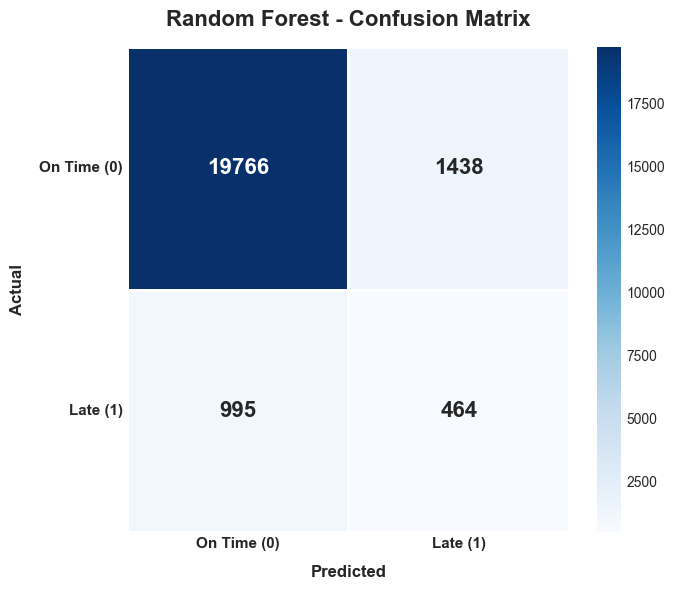


### Confusion Matrix Interpretation

The model correctly identified **19,766 On-Time orders** (True Negatives)
and **464 Late orders** (True Positives).

It incorrectly predicted **1,438 On-Time orders as Late** (False Positives).

More importantly, **995 Late orders were predicted as On Time**
(False Negatives).

**Business Focus:** The **995 False Negatives** represent late deliveries
that the model failed to identify in advance. Reducing these errors can help
the business anticipate delays and improve delivery planning.


In [81]:
cm = confusion_matrix(y_test, rf_pred)

os.makedirs('../visuals', exist_ok=True)

plt.figure(figsize=(7, 6))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2,
    linecolor='white',
    cbar=True,
    annot_kws={
        'fontsize': 16,
        'fontweight': 'bold'
    },
    xticklabels=['On Time (0)', 'Late (1)'],
    yticklabels=['On Time (0)', 'Late (1)']
)

plt.xlabel(
    'Predicted',
    fontsize=12,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    'Actual',
    fontsize=12,
    fontweight='bold',
    labelpad=10
)

plt.title(
    'Random Forest - Confusion Matrix',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xticks(
    fontsize=11,
    fontweight='bold'
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    rotation=0
)

plt.tight_layout()
plt.savefig('../visuals/01.Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()


display(Markdown(f"""
### Confusion Matrix Interpretation

The model correctly identified **{tn:,} On-Time orders** (True Negatives)
and **{tp:,} Late orders** (True Positives).

It incorrectly predicted **{fp:,} On-Time orders as Late** (False Positives).

More importantly, **{fn:,} Late orders were predicted as On Time**
(False Negatives).

**Business Focus:** The **{fn:,} False Negatives** represent late deliveries
that the model failed to identify in advance. Reducing these errors can help
the business anticipate delays and improve delivery planning.
"""))

### Insight
- **What happened?** The Tuned Random Forest correctly identified 19,766 on-time deliveries and 464 late deliveries. However, it missed 995 actual late orders (False Negatives) and falsely flagged 1,438 on-time orders as late (False Positives).
- **ML meaning:** Despite hyperparameter tuning, the model struggles with minority class Recall (only catching about 32% of actual late deliveries). The severe class imbalance causes the model to lean towards predicting "On Time".
- **Business meaning:** While the business can proactively assist the 464 correctly identified late orders, they will still face angry support tickets from the 995 customers whose delays were completely missed by the model.
- **Action / recommendation:** If the business prioritizes customer satisfaction over cost, they should lower the model's decision threshold to aggressively flag more orders as "Late", trading higher false alarms for better delay detection.
- **Limitation:** Extreme class imbalance inherently limits the model's ability to catch true positives without artificially oversampling.


### ROC Curve 

The ROC Curve evaluates the model's ability to distinguish between on-time orders (0) and late orders (1) across different classification thresholds.

The **ROC-AUC score** summarizes the model's overall discrimination ability:
- AUC close to **1.0** → excellent discrimination
- AUC around **0.5** → no better than random guessing

The curve below shows the performance of the Random Forest model.

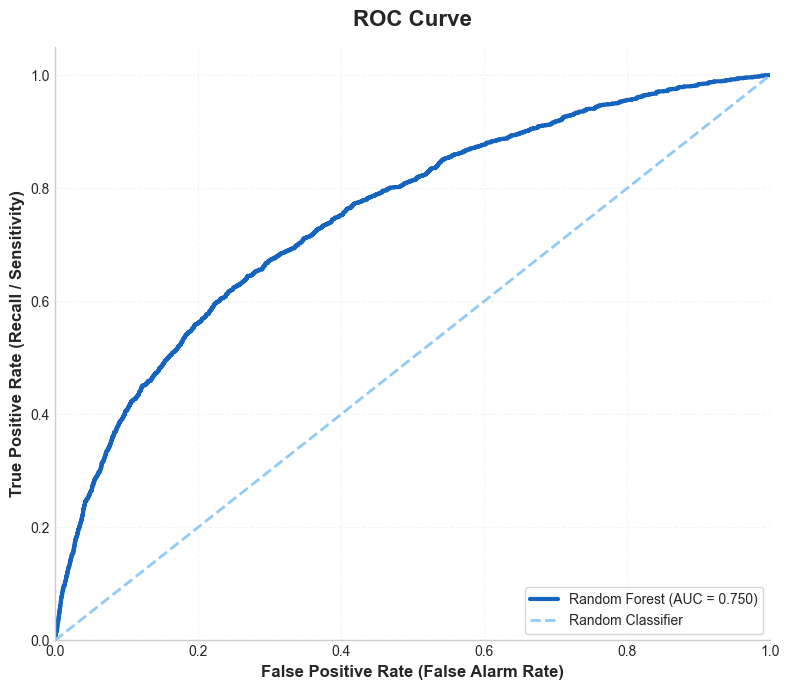

ROC-AUC: 0.7501


In [82]:
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    color='#1565C0',
    linewidth=3,
    label=f'Random Forest (AUC = {roc_auc:.3f})'
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    color='#90CAF9',
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    'False Positive Rate (False Alarm Rate)',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'True Positive Rate (Recall / Sensitivity)',
    fontsize=12,
    fontweight='bold'
)

plt.title(
    'ROC Curve',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.legend(
    loc='lower right',
    fontsize=10,
    frameon=True
)

plt.grid(
    alpha=0.2,
    linestyle='--'
)

# Axis limits
plt.xlim([0, 1])
plt.ylim([0, 1.05])

# Clean appearance
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/02.ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

### Insight
- **What happened?** The ROC Curve sits solidly above the random classifier line, achieving an Area Under the Curve (AUC) of 0.750.
- **ML meaning:** An AUC of 0.750 indicates the Random Forest has a strong, mathematically reliable ability to distinguish between on-time and late deliveries across all possible classification thresholds.
- **Business meaning:** The model provides a reliable foundation for predicting late deliveries, offering a massive 25% improvement over guessing randomly.
- **Action / recommendation:** The logistics team can confidently use the model's raw probability scores (e.g., "75% chance of being late") to rank high-risk orders on a dashboard for daily review.
- **Limitation:** While 0.750 is good, external unmeasured factors (like sudden traffic accidents or strikes) prevent the model from reaching a near-perfect score.


### Feature Importance 

Feature importance shows the relative contribution of each feature to the
Random Forest model's predictions.

The chart below presents the **Top 15 most important features** used by the
model to predict whether an order will be delivered late.

Higher importance indicates that the feature had a greater influence on the
model's predictions.

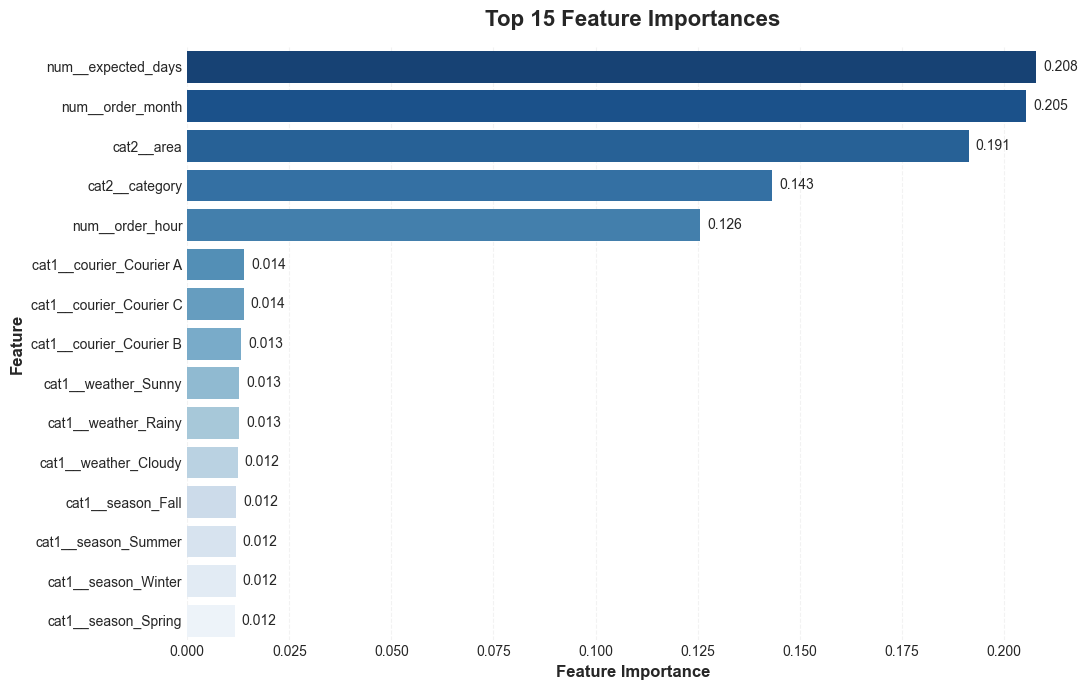

In [83]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=5,
        fontsize=10
    )

plt.xlabel(
    'Feature Importance',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold'
)

plt.title(
    'Top 15 Feature Importances',
    fontsize=16,
    fontweight='bold',
    pad=15
)

sns.despine(left=True, bottom=True)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()
plt.savefig('../visuals/03.Top_15_Feature_Importances.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
- **What happened?** The top 3 most important features driving delays are `expected_days` (20.8%), `order_month` (20.5%), and `area` (19.1%). `Courier`, `weather`, and `season` had almost zero importance (<1.5%).
- **ML meaning:** The model almost entirely ignores courier and weather data, heavily prioritizing temporal and spatial features to make its splits and predictions.
- **Business meaning:** Delays are driven almost entirely by *when* and *where* an order is placed, rather than *who* is delivering it or what the weather is like outside.
- **Action / recommendation:** Logistics managers should focus on optimizing routes for specific geographic areas and increasing warehouse staff during problematic months, rather than penalizing specific couriers.
- **Limitation:** Because `courier`, `weather`, and `season` were synthetically simulated in the data prep phase, their low importance is likely a byproduct of random simulation rather than reflecting true real-world logistics performance.


In [84]:
model_comparison = cv_results_df.copy()

# Keep only the five required metrics
model_comparison = model_comparison[
    [
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc'
    ]
]

# Rename columns for the report
model_comparison.columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC'
]

# Add Tuned column
model_comparison['Tuned'] = 'Yes'

# Add Selected column
model_comparison['Selected'] = 'No'

# Select the final model
model_comparison.loc['Random Forest', 'Selected'] = 'Yes'

# Save CSV inside the reports folder
model_comparison.to_csv(
    '../reports/model_comparison.csv'
)

print("model_comparison.csv created successfully.")

display(model_comparison)

model_comparison.csv created successfully.


,Accuracy,Precision,Recall,F1,ROC-AUC,Tuned,Selected
Dummy (majority class),0.935632,0.000000,0.000000,0.000000,0.500000,Yes,No
Random Forest,0.934297,0.332012,0.020223,0.038097,0.705996,Yes,Yes
Decision Tree,0.893228,0.175658,0.178578,0.177084,0.560505,Yes,No
Logistic Regression,0.675624,0.109235,0.564696,0.183053,0.673939,Yes,No
KNN,0.728122,0.093530,0.370865,0.149380,0.585348,Yes,No
